C:\Users\DellU\AppData\Local\Temp\ipykernel_19304\2968133403.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='viridis')


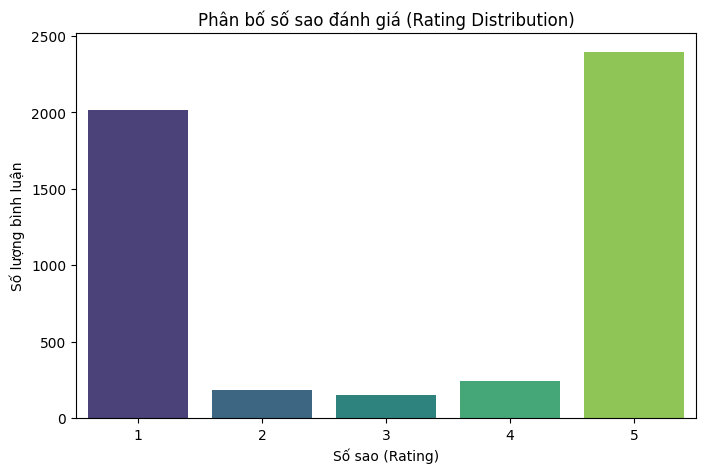

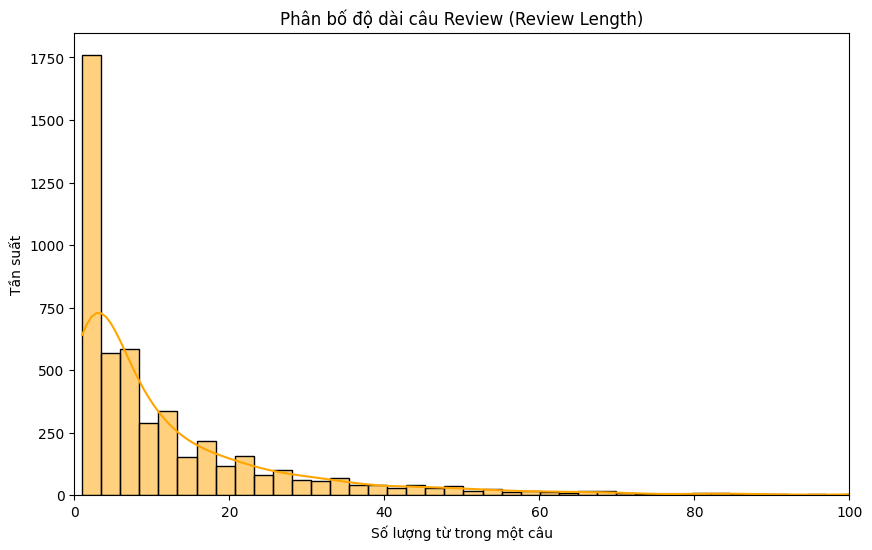

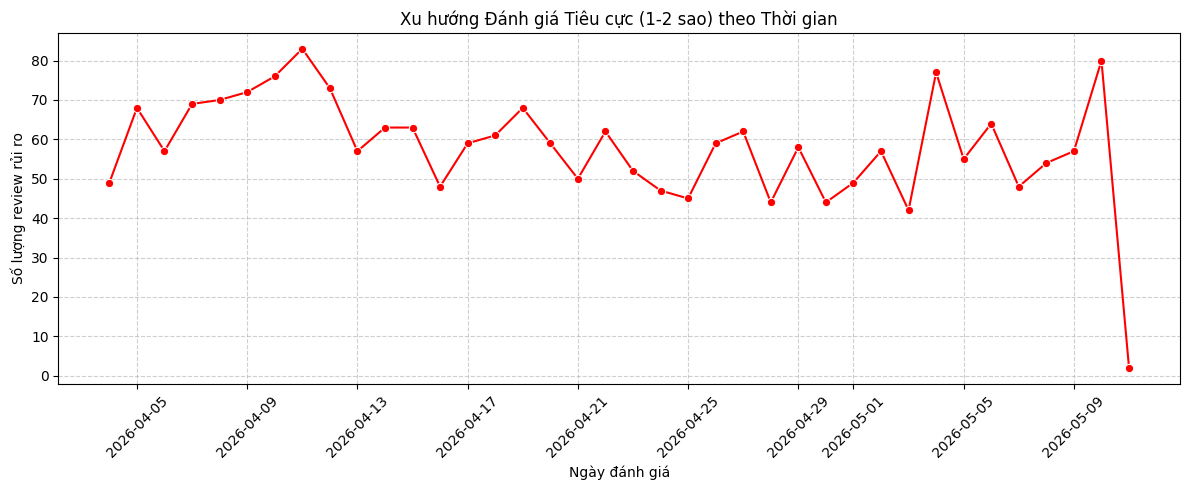

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Đường dẫn file dữ liệu (Của bạn đã đúng)
data_path = r'D:\NNLT_PYTHON\GroupPython\d-o-n-nguy-c-kh-ch-h-ng-r-i-b-th-ng-qua-c-c-t-n-hi-u-b-t-m-n-trong-v-n-b-n-nh-gi-\project\data\raw\Shopee_Reviews_withTime.csv'

# ========================================================
# SỬA Ở ĐÂY: Dùng đường dẫn tuyệt đối cho thư mục kết quả
# ========================================================
results_path = r'D:\NNLT_PYTHON\GroupPython\d-o-n-nguy-c-kh-ch-h-ng-r-i-b-th-ng-qua-c-c-t-n-hi-u-b-t-m-n-trong-v-n-b-n-nh-gi-\project\results'

# SỬA Ở ĐÂY: Lệnh yêu cầu tự động tạo thư mục 'results' nếu nó chưa có
os.makedirs(results_path, exist_ok=True)
# ========================================================

df = pd.read_csv(data_path)
df['review_date'] = pd.to_datetime(df['review_date'])

# --- Vẽ biểu đồ 1 ---
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=df, palette='viridis')
plt.title('Phân bố số sao đánh giá (Rating Distribution)')
plt.xlabel('Số sao (Rating)')
plt.ylabel('Số lượng bình luận')
plt.savefig(os.path.join(results_path, 'rating_distribution.png'))
plt.show()

# --- Vẽ biểu đồ 2 ---
df['review_length'] = df['review_text'].astype(str).apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 6))
sns.histplot(df['review_length'], bins=50, kde=True, color='orange')
plt.title('Phân bố độ dài câu Review (Review Length)')
plt.xlabel('Số lượng từ trong một câu')
plt.ylabel('Tần suất')
plt.xlim(0, 100)
plt.savefig(os.path.join(results_path, 'review_length.png'))
plt.show()

# --- Vẽ biểu đồ 3 ---
df['date_only'] = df['review_date'].dt.date
risk_trend = df[df['rating'] <= 2].groupby('date_only').size().reset_index(name='count')
plt.figure(figsize=(12, 5))
sns.lineplot(x='date_only', y='count', data=risk_trend, marker='o', color='red')
plt.title('Xu hướng Đánh giá Tiêu cực (1-2 sao) theo Thời gian')
plt.xlabel('Ngày đánh giá')
plt.ylabel('Số lượng review rủi ro')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(results_path, 'high_risk_trend.png'))
plt.show()